In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# プロジェクトのsrcディレクトリをimportパスに追加
import os
import sys

output_path = os.path.abspath(os.path.join('..', 'output/sar'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
params_df = pd.read_csv(os.path.join(output_path, "parameters.csv"))
metadata_df = pd.read_csv(os.path.join(output_path, "metadata.csv"))
metadata_dict = dict(zip(metadata_df["項目"], metadata_df["値"]))

display(params_df)
for key, value in metadata_dict.items():
    print(f"{key}: {value}")

,N,k_ave,lambdaMin,lambdaMax,dlambda,gamma,rho0Min,rho0Max,drho0,T,tmax,batchNum,itrPerBatch
0,4000,10,0.0,1.0,0.01,1.0,0.0,1.0,0.01,3,50,12,10


シミュレーション開始時間: 2025-08-09 11:06:38
シミュレーション終了時間: 2025-08-09 14:09:51


In [ ]:
network_type = params_df["networkType"].values[0]
N = params_df["N"].values[0]
k_ave = params_df["k_ave"].values[0]
lambda_min = params_df["lambdaMin"].values[0]
lambda_max = params_df["lambdaMax"].values[0]
dlambda = params_df["dlambda"].values[0]
gamma = params_df["gamma"].values[0]
rho0_min = params_df["rho0Min"].values[0]
rho0_max = params_df["rho0Max"].values[0]
drho0 = params_df["drho0"].values[0]
T = params_df["T"].values[0]
tmax = params_df["tmax"].values[0]
batch_num = params_df["batchNum"].values[0]
itr_per_batch = params_df["itrPerBatch"].values[0]

In [6]:
total_itr = batch_num * itr_per_batch
lambda_values = np.arange(lambda_min, lambda_max + dlambda, dlambda)
rho0_values = np.arange(rho0_min, rho0_max + drho0, drho0)

shape = (len(lambda_values), len(rho0_values), total_itr, tmax+1)
len_per_state = len(lambda_values) * len(rho0_values) * itr_per_batch * (tmax + 1)
S, A, R = np.zeros(shape), np.zeros(shape), np.zeros(shape)

for batch_idx in range(batch_num):
    file_name = os.path.join(output_path, f"results_{batch_idx}.csv")
    print(f"Downloading {(batch_idx + 1):02d} th file ...")
    values = np.loadtxt(file_name, delimiter=",", skiprows=1)
    reshaped = values.reshape((3, len(lambda_values), len(rho0_values), itr_per_batch, tmax+1))

    S[:, :, batch_idx * itr_per_batch:(batch_idx + 1) * itr_per_batch, :] = reshaped[0]
    A[:, :, batch_idx * itr_per_batch:(batch_idx + 1) * itr_per_batch, :] = reshaped[1]
    R[:, :, batch_idx * itr_per_batch:(batch_idx + 1) * itr_per_batch, :] = reshaped[2]

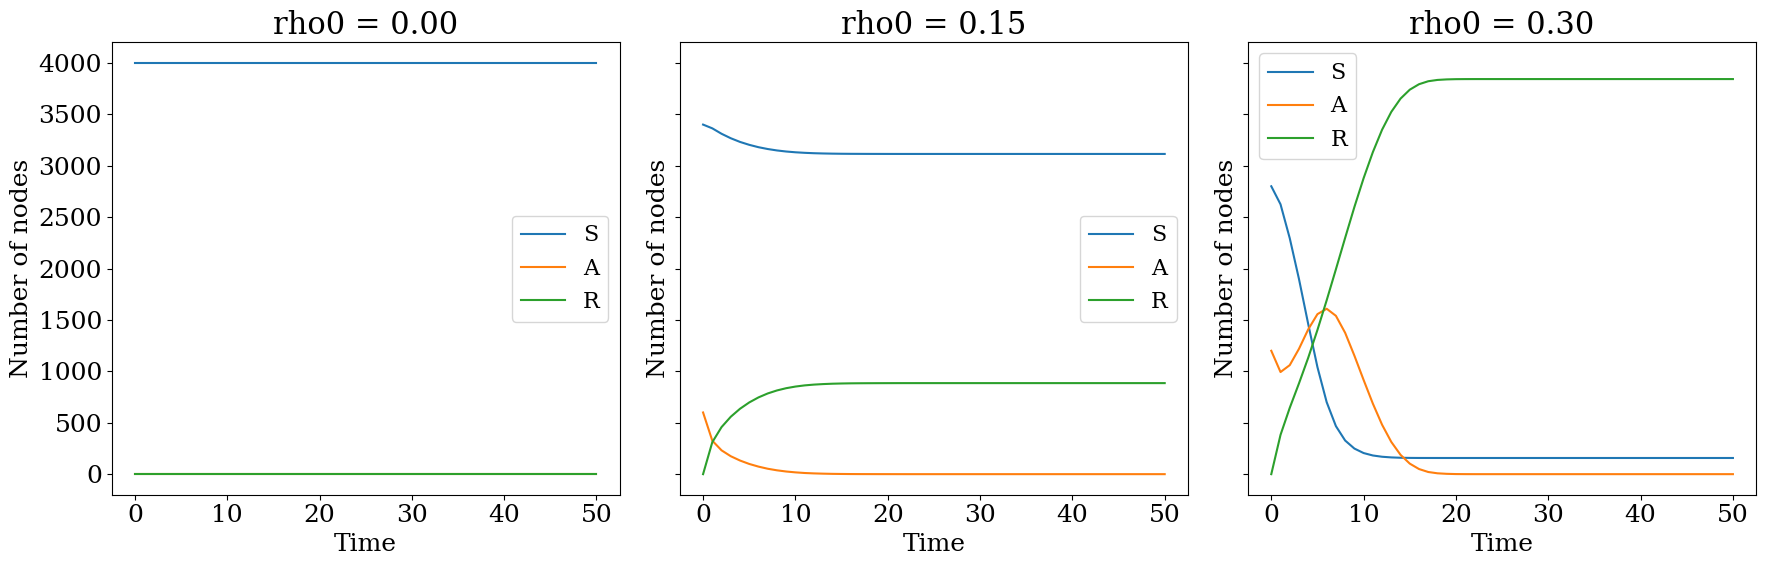

In [7]:
times = np.arange(tmax + 1)

lamdbda_idx = 30

rho0_idx_list = [0, 15, 30]

fig, axes = plt.subplots(1, len(rho0_idx_list), figsize=(6 * len(rho0_idx_list), 6), sharey=True)
for idx, rho0_idx in enumerate(rho0_idx_list):
    rho0 = rho0_values[rho0_idx]
    plot_S = S[lamdbda_idx, rho0_idx, :, :].mean(axis=0)
    plot_A = A[lamdbda_idx, rho0_idx, :, :].mean(axis=0)
    plot_R = R[lamdbda_idx, rho0_idx, :, :].mean(axis=0)
    axes[idx].plot(times, plot_S, label="S")
    axes[idx].plot(times, plot_A, label="A")
    axes[idx].plot(times, plot_R, label="R")
    axes[idx].legend()
    axes[idx].set_title(f"rho0 = {rho0:.2f}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Number of nodes")
    # axes[idx].set_xlim(0, 5)

plt.tight_layout()
plt.show()

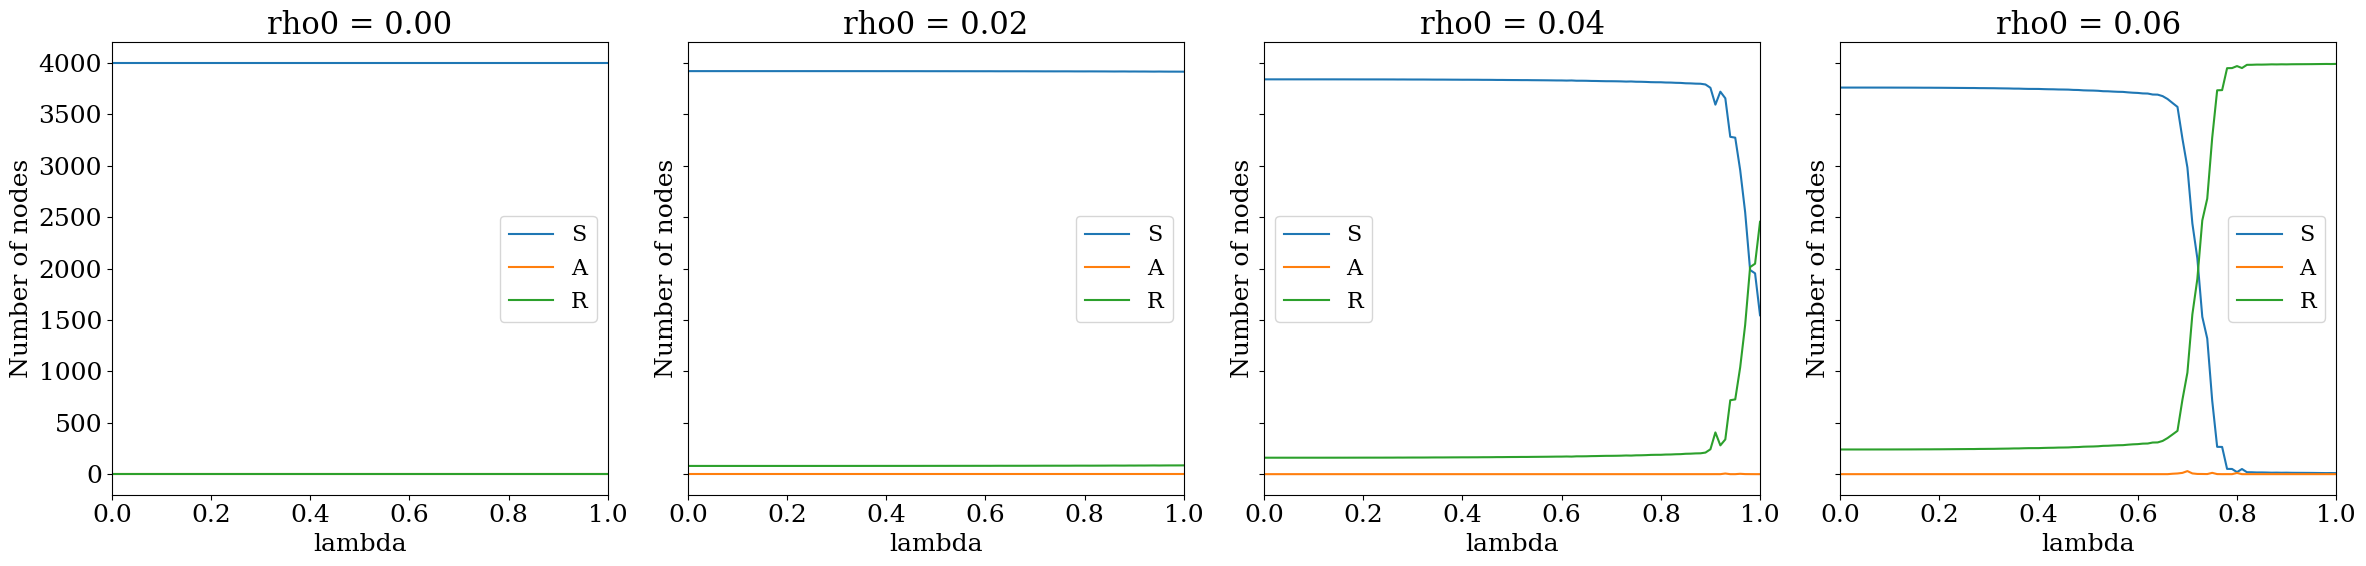

In [8]:
rho0_idx_list = [0, 2, 4, 6]

fig, axes = plt.subplots(1, len(rho0_idx_list), figsize=(6 * len(rho0_idx_list), 6), sharey=True)
for idx, rho0_idx in enumerate(rho0_idx_list):
    rho0 = rho0_values[rho0_idx]
    plot_S = S[:, rho0_idx, :, -1].mean(axis=1)
    plot_A = A[:, rho0_idx, :, -1].mean(axis=1)
    plot_R = R[:, rho0_idx, :, -1].mean(axis=1)
    axes[idx].plot(lambda_values, plot_S, label="S")
    axes[idx].plot(lambda_values, plot_A, label="A")
    axes[idx].plot(lambda_values, plot_R, label="R")
    axes[idx].legend()
    axes[idx].set_title(f"rho0 = {rho0:.2f}")
    axes[idx].set_xlabel("lambda")
    axes[idx].set_ylabel("Number of nodes")
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()

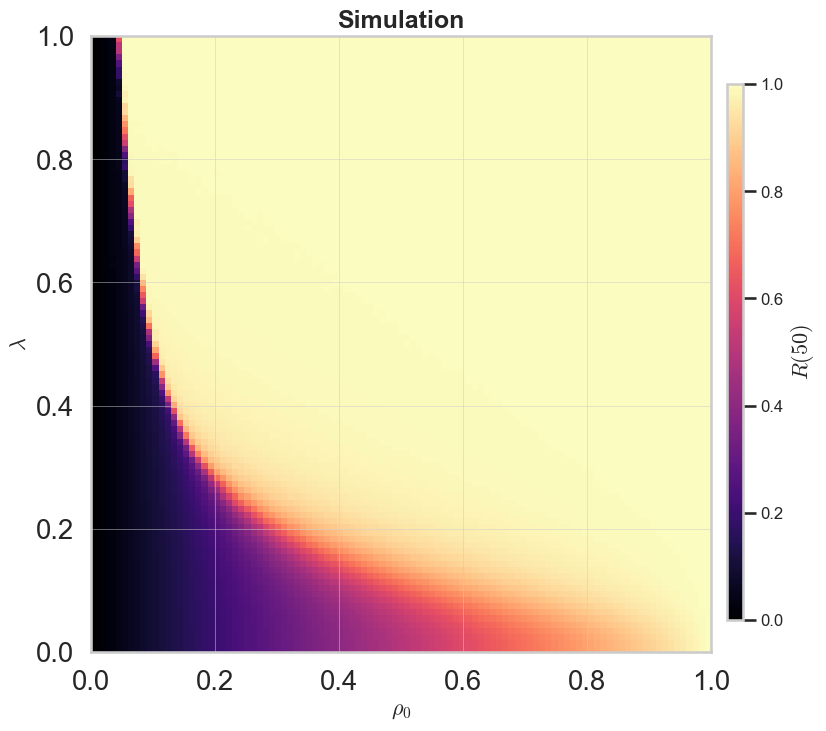

In [9]:
# Seabornスタイルを使用
sns.set_context("talk", font_scale=1.2)
sns.set_style("whitegrid")

# 図の準備
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(1, 1, width_ratios=[1], figure=fig)

# カラーマップの範囲を統一
vmin = 0
vmax = 1

# サブプロット1: シミュレーション結果
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(
    (R[:,:,:,-1] / N).mean(axis=2),
    extent=[0.0, 1.0, 0.0, 1.0],
    origin='lower',
    aspect='auto',
    cmap='magma',
    vmin=vmin,
    vmax=vmax
)
ax1.set_title("Simulation", fontsize=18, weight='bold')
ax1.set_xlabel(r"$\rho_0$", fontsize=16, weight='bold')
ax1.set_ylabel(r"$\lambda$", fontsize=16)
ax1.grid(linewidth=0.5, alpha=0.7)  # グリッドを細く

# サブプロット2: 理論結果
# ax2 = fig.add_subplot(gs[0, 1])
# im2 = ax2.imshow(
#     r_t_ana[:,:,-1],
#     extent=[0.0, 1.0, 0.0, 1.1],
#     origin='lower',
#     aspect='auto',
#     cmap='magma',
#     vmin=vmin,
#     vmax=vmax
# )
# ax2.set_title("Analytical", fontsize=18, weight='bold')
# ax2.set_xlabel(r"$\lambda$", fontsize=16, weight='bold')
# ax2.set_ylabel("")
# ax2.grid(linewidth=0.5, alpha=0.7)  # グリッドを細く

# # カラーバーを全体で共有
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.67])  # 位置: [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label(rf"$R({tmax})$", fontsize=16, weight='bold')
cbar.ax.tick_params(labelsize=12)

# レイアウト調整
plt.show()
